# KNN Classifier — Predicting Low vs High Tip

Using the seaborn **tips** dataset to predict whether a customer leaves a
*low* or *high* tip based on the bill amount, party size, and other features.

The tip is split into **low (0)** and **high (1)** at the median value.

## 1. Import libraries

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

## 2. Load the dataset
The `tips` dataset is built into seaborn.

In [2]:
df = sns.load_dataset("tips")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 3. Create the target label
There is no ready-made low/high column, so we build one using the **median tip**
as the cut-off. This gives a balanced split.

In [3]:
median_tip = df["tip"].median()
df["tip_class"] = (df["tip"] > median_tip).astype(int)   # 1 = high, 0 = low

print("Median tip (cut-off):", median_tip)
df["tip_class"].value_counts()

Median tip (cut-off): 2.9


tip_class
0    122
1    122
Name: count, dtype: int64

## 4. Features and target
The raw `tip` column is dropped from the features so the model does not
simply read off the answer.

In [4]:
X = df.drop(columns=["tip", "tip_class"])
y = df["tip_class"]

## 5. Encode categorical columns
KNN needs numeric input, so text columns are one-hot encoded.

In [5]:
X = pd.get_dummies(X, columns=["sex", "smoker", "day", "time"],
                   drop_first=True)
list(X.columns)

['total_bill',
 'size',
 'sex_Female',
 'smoker_No',
 'day_Fri',
 'day_Sat',
 'day_Sun',
 'time_Dinner']

## 6. Train / test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## 7. Scale the features
KNN is distance-based, so features are scaled to a comparable range
(otherwise `total_bill` would dominate).

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Choose k
Try k from 1 to 20 and keep the value with the best test accuracy.

In [8]:
scores = {}
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scores[k] = accuracy_score(y_test, knn.predict(X_test_scaled))

best_k = max(scores, key=scores.get)
print("Best k:", best_k)

Best k: 5


## 9. Train the final model

In [9]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

## 10. Evaluate

In [10]:
print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=["Low", "High"]))

Test Accuracy: 0.714

Confusion Matrix:
 [[21  4]
 [10 14]]

Classification Report:
               precision    recall  f1-score   support

         Low       0.68      0.84      0.75        25
        High       0.78      0.58      0.67        24

    accuracy                           0.71        49
   macro avg       0.73      0.71      0.71        49
weighted avg       0.73      0.71      0.71        49



## 11. Predict on a new customer

In [11]:
new_customer = pd.DataFrame([{
    "total_bill": 25.0, "size": 3,
    "sex_Female": 0, "smoker_No": 1,
    "day_Fri": 0, "day_Sat": 1, "day_Sun": 0,
    "time_Dinner": 1
}])
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)
pred = model.predict(scaler.transform(new_customer))[0]
print("New customer prediction:", "High tip" if pred == 1 else "Low tip")

New customer prediction: High tip


## 12. Plot accuracy vs k

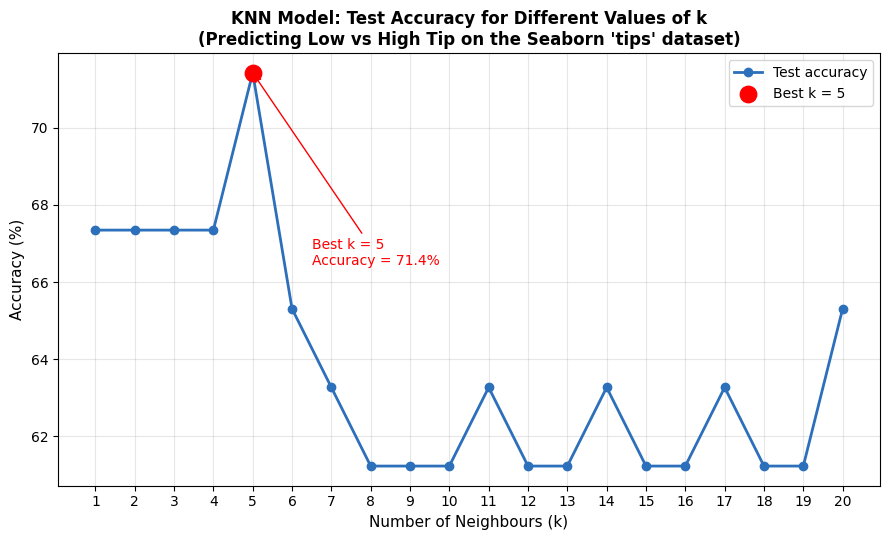

In [12]:
k_values = list(scores.keys())
accuracies = [s * 100 for s in scores.values()]
best_acc = scores[best_k] * 100

plt.figure(figsize=(9, 5.5))
plt.plot(k_values, accuracies, marker="o", color="#2c6fbb",
         linewidth=2, label="Test accuracy")
plt.scatter([best_k], [best_acc], color="red", s=140, zorder=5,
            label=f"Best k = {best_k}")
plt.annotate(f"Best k = {best_k}\nAccuracy = {best_acc:.1f}%",
             xy=(best_k, best_acc),
             xytext=(best_k + 1.5, best_acc - 5),
             arrowprops=dict(arrowstyle="->", color="red"),
             fontsize=10, color="red")
plt.title("KNN Model: Test Accuracy for Different Values of k\n"
          "(Predicting Low vs High Tip on the Seaborn 'tips' dataset)",
          fontsize=12, fontweight="bold")
plt.xlabel("Number of Neighbours (k)", fontsize=11)
plt.ylabel("Accuracy (%)", fontsize=11)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()